Note that there will be EDA and Data Cleaning in this notebook as well, mainly for the newly engineered features.

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import os

In [22]:
df = pd.read_csv("../data/processed/csgo_cleaned_2.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 864980 entries, 0 to 864979
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       864980 non-null  int64  
 1   file             864980 non-null  str    
 2   map              864980 non-null  str    
 3   date             864980 non-null  str    
 4   round            864980 non-null  int64  
 5   tick             864980 non-null  int64  
 6   seconds          864980 non-null  float64
 7   att_team         864980 non-null  str    
 8   vic_team         864980 non-null  str    
 9   att_side         864980 non-null  str    
 10  vic_side         864980 non-null  str    
 11  hp_dmg           864980 non-null  int64  
 12  arm_dmg          864980 non-null  int64  
 13  is_bomb_planted  864980 non-null  bool   
 14  bomb_site        133956 non-null  str    
 15  hitbox           864980 non-null  str    
 16  wp               864980 non-null  str    
 17  wp

In [23]:
df2 = df.drop(columns=['date', 'tick', 'seconds', 'award', 'vic_id', 'ct_eq_val', 't_eq_val', 'map_1'])
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 864980 entries, 0 to 864979
Data columns (total 32 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       864980 non-null  int64  
 1   file             864980 non-null  str    
 2   map              864980 non-null  str    
 3   round            864980 non-null  int64  
 4   att_team         864980 non-null  str    
 5   vic_team         864980 non-null  str    
 6   att_side         864980 non-null  str    
 7   vic_side         864980 non-null  str    
 8   hp_dmg           864980 non-null  int64  
 9   arm_dmg          864980 non-null  int64  
 10  is_bomb_planted  864980 non-null  bool   
 11  bomb_site        133956 non-null  str    
 12  hitbox           864980 non-null  str    
 13  wp               864980 non-null  str    
 14  wp_type          864980 non-null  str    
 15  winner_team      864980 non-null  str    
 16  winner_side      864980 non-null  str    
 17  at

In [24]:
# df2["att_pos_x_scaled"] = (df2["att_pos_x"] - df2["StartX"]) / (df2["EndX"] - df2["StartX"])
# df2["att_pos_y_scaled"] = (df2["att_pos_y"] - df2["StartY"]) / (df2["EndY"] - df2["StartY"])
# df2["vic_pos_x_scaled"] = (df2["vic_pos_x"] - df2["StartX"]) / (df2["EndX"] - df2["StartX"])
# df2["vic_pos_y_scaled"] = (df2["att_pos_y"] - df2["StartY"]) / (df2["EndY"] - df2["StartY"])

# df2["vic_pos_y_scaled"].describe()

# above might not be necessary

In [25]:
import numpy as np

To simplify coordinate data into scalars, we will make three new features: the in-between distance of the attacker and the victim, the attacker's distance to the nearest bombsite, and the victim's distance to the nearest bombsite.

In [26]:
df2["inbetween_distance"] = np.sqrt(np.square(df2["att_pos_x"] - df2["vic_pos_x"]) + np.square(df2["att_pos_y"] - df2["vic_pos_y"]))
print(df2.info())
print(df2["inbetween_distance"].describe())

<class 'pandas.DataFrame'>
RangeIndex: 864980 entries, 0 to 864979
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          864980 non-null  int64  
 1   file                864980 non-null  str    
 2   map                 864980 non-null  str    
 3   round               864980 non-null  int64  
 4   att_team            864980 non-null  str    
 5   vic_team            864980 non-null  str    
 6   att_side            864980 non-null  str    
 7   vic_side            864980 non-null  str    
 8   hp_dmg              864980 non-null  int64  
 9   arm_dmg             864980 non-null  int64  
 10  is_bomb_planted     864980 non-null  bool   
 11  bomb_site           133956 non-null  str    
 12  hitbox              864980 non-null  str    
 13  wp                  864980 non-null  str    
 14  wp_type             864980 non-null  str    
 15  winner_team         864980 non-null  str    


In [27]:
# just mirage first for modeling purposes, will do all maps maybe
df2["bombsite_a_x"] = np.where(df["map"] == "de_mirage", -390, np.nan)
df2["bombsite_a_y"] = np.where(df["map"] == "de_mirage", -2090, np.nan)
df2["bombsite_b_x"] = np.where(df["map"] == "de_mirage", -2160, np.nan)
df2["bombsite_b_y"] = np.where(df["map"] == "de_mirage", -280, np.nan)
df2["bombsite_a_att_distance"] = np.sqrt(np.square(df2["att_pos_x"] - df2["bombsite_a_x"]) + np.square(df2["att_pos_y"] - df2["bombsite_a_y"]))
df2["bombsite_b_att_distance"] = np.sqrt(np.square(df2["att_pos_x"] - df2["bombsite_b_x"]) + np.square(df2["att_pos_y"] - df2["bombsite_b_y"]))
df2["bombsite_a_vic_distance"] = np.sqrt(np.square(df2["vic_pos_x"] - df2["bombsite_a_x"]) + np.square(df2["vic_pos_y"] - df2["bombsite_a_y"]))
df2["bombsite_b_vic_distance"] = np.sqrt(np.square(df2["vic_pos_x"] - df2["bombsite_b_x"]) + np.square(df2["vic_pos_y"] - df2["bombsite_b_y"]))
df2["att_distance_to_bombsite"] = np.where(df2["map"] == "de_mirage", np.minimum(df2["bombsite_a_att_distance"], df2["bombsite_b_att_distance"]), np.nan)
df2["vic_distance_to_bombsite"] = np.where(df2["map"] == "de_mirage", np.minimum(df2["bombsite_a_vic_distance"], df2["bombsite_b_vic_distance"]), np.nan)
df3 = df2.drop(columns=["bombsite_a_att_distance", "bombsite_b_att_distance", "bombsite_a_vic_distance", "bombsite_b_vic_distance",
                       "bombsite_a_x", "bombsite_a_y", "bombsite_b_x", "bombsite_b_y"])
print(df3["att_distance_to_bombsite"].describe())
print(df3["vic_distance_to_bombsite"].describe())

count    253980.000000
mean        930.910409
std         514.849055
min           1.284384
25%         531.879575
50%         906.452470
75%        1214.799493
max        3122.870253
Name: att_distance_to_bombsite, dtype: float64
count    253980.000000
mean        934.664519
std         508.385555
min           1.222473
25%         545.194818
50%         914.239747
75%        1212.589776
max        3142.344449
Name: vic_distance_to_bombsite, dtype: float64


Assuming that the precise calculations for armor penetration will not skew our data, we will combine armor damage and hp damage.

In [28]:
df3["total_dmg"] = df3["hp_dmg"] + df3["arm_dmg"]
df3["is_headshot"] = df3["hitbox"] == "Head"
df5 = df3.drop(columns=["hp_dmg", "arm_dmg", "hitbox"]) # skipped df4 because it makes everything else easier
print(df5["is_headshot"].describe())

count     864980
unique         2
top        False
freq      761959
Name: is_headshot, dtype: object


In [29]:
tier_boundaries = [0, 6, 10, 14, 18]
tiers = ["Silver", "Gold Nova", "Master Guardian", "Top Four"]

df5["att_tier"] = pd.cut(df5["att_rank"], bins=tier_boundaries, labels=tiers)
df5["vic_tier"] = pd.cut(df5["vic_rank"], bins=tier_boundaries, labels=tiers)
df5["att_tier"].describe()

count              864980
unique                  4
top       Master Guardian
freq               381974
Name: att_tier, dtype: object

In [30]:
from pandas.api.types import CategoricalDtype

custom_order = CategoricalDtype(categories=['Silver', 'Gold Nova', 'Master Guardian', 'Top Four'], ordered=True)
df5["att_tier"] = df5["att_tier"].astype(custom_order)
df5["vic_tier"] = df5["vic_tier"].astype(custom_order)

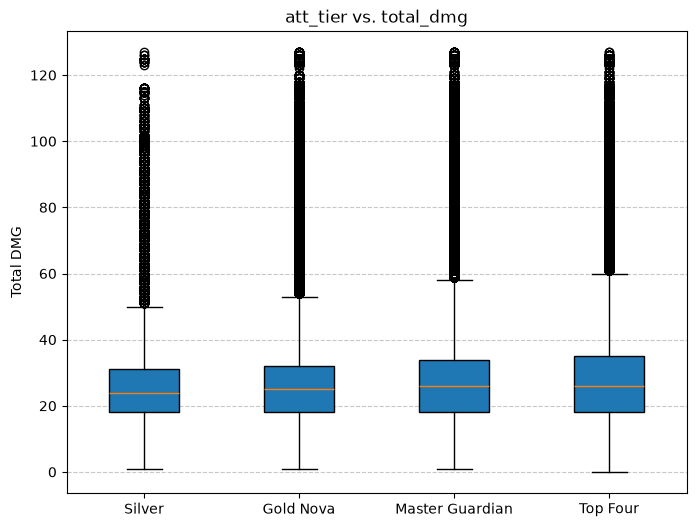

In [31]:
sorted_data = [df5.loc[df5["att_tier"] == "Silver", "total_dmg"], df5.loc[df5["att_tier"] == "Gold Nova", "total_dmg"], 
    df5.loc[df5["att_tier"] == "Master Guardian", "total_dmg"], df5.loc[df5["att_tier"] == "Top Four", "total_dmg"]]
labels = ['Silver', 'Gold Nova', 'Master Guardian', 'Top Four']

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(sorted_data, patch_artist=True, tick_labels=labels)
ax.set_title('att_tier vs. total_dmg')
ax.set_ylabel('Total DMG')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../images/04_total_dmg.png")
plt.show()

It doesn't make sense for a damage entry dataset to have total_dmg values being zero. Let's filter that:

In [32]:
df6 = df5[df5["total_dmg"] > 0]
df6.shape

(864979, 36)

In [33]:
ct = pd.crosstab(df6["is_bomb_planted"], df6["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
is_bomb_planted,,,,
False,15214,280481,324786,110542
True,2675,54669,57188,19424


In [34]:
ct = pd.crosstab(df6["round_type"], df6["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
round_type,,,,
ECO,3314,73695,106909,39583
FORCE_BUY,3412,56422,52798,16537
NORMAL,8211,154320,166738,54861
PISTOL_ROUND,1450,27249,29516,9988
SEMI_ECO,1502,23464,26013,8997


In [35]:
ct = pd.crosstab(df6["wp"], df6["att_tier"])
ct

att_tier,Silver,Gold Nova,Master Guardian,Top Four
wp,,,,
AK47,3563,73907,94720,34238
AUG,375,4131,2226,337
AWP,452,12640,16684,6543
Bizon,341,3168,2233,459
Bomb,0,0,0,1
CZ,103,2551,4479,2069
Deagle,253,7110,9957,4477
Decoy,0,6,2,0
DualBarettas,49,793,660,121


In [36]:
print(df6["inbetween_distance"].describe())
print(df6[df6["inbetween_distance"] > 0].describe())

count    864979.000000
mean        675.423653
std         410.614043
min           0.000000
25%         363.020200
50%         610.332346
75%         917.319176
max        3816.805781
Name: inbetween_distance, dtype: float64
          Unnamed: 0          round        att_id       att_rank  \
count  861450.000000  861450.000000  8.614500e+05  861450.000000   
mean      382.067935      13.527732  7.656120e+16      11.413608   
std       234.442218       7.861115  1.270539e+08       2.742021   
min         0.000000       1.000000  7.656120e+16       1.000000   
25%       183.000000       7.000000  7.656120e+16       9.000000   
50%       369.000000      13.000000  7.656120e+16      11.000000   
75%       563.000000      20.000000  7.656120e+16      13.000000   
max      1159.000000      30.000000  7.656120e+16      18.000000   

            vic_rank      att_pos_x      att_pos_y      vic_pos_x  \
count  861450.000000  861450.000000  861450.000000  861450.000000   
mean       11.319373    

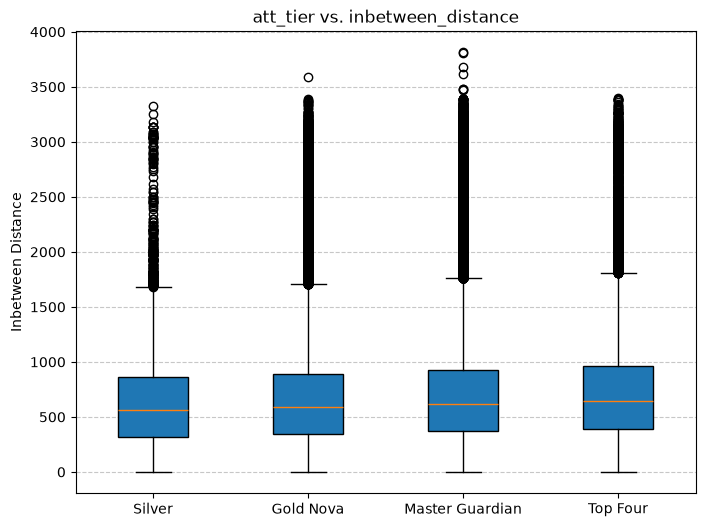

In [37]:
sorted_data = [df6.loc[df6["att_tier"] == "Silver", "inbetween_distance"], df6.loc[df6["att_tier"] == "Gold Nova", "inbetween_distance"], 
    df6.loc[df6["att_tier"] == "Master Guardian", "inbetween_distance"], df6.loc[df6["att_tier"] == "Top Four", "inbetween_distance"]]
labels = ['Silver', 'Gold Nova', 'Master Guardian', 'Top Four']

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(sorted_data, patch_artist=True, tick_labels=labels)
ax.set_title('att_tier vs. inbetween_distance')
ax.set_ylabel('Inbetween Distance')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../images/04_inbetween_distance.png")
plt.show()

In [38]:
df6["wp"].value_counts()

wp
AK47            206428
M4A4             78314
M4A1             55651
UMP              50352
P90              44279
USP              43188
Glock            41546
Incendiary       39265
AWP              36319
HE               33186
MP7              29363
P250             24523
Deagle           21797
Mac10            19109
Famas            18302
FiveSeven        15741
MP9              13465
Gallil           11334
Tec9             10384
CZ                9202
SG556             8001
P2000             7639
Scout             7372
AUG               7069
XM1014            6370
Bizon             6201
Swag7             5453
Nova              4648
Knife             2144
DualBarettas      1623
Negev             1334
Scar20            1104
G3SG1             1058
SawedOff           931
Molotov            641
Smoke              622
Flash              596
M249               224
Zeus               188
Decoy                8
Unknown              4
Bomb                 1
Name: count, dtype: int64

Since we are mostly interested in positioning, we are interested in non-melee weapons. Hence, we will drop: Knife, Zeus, HE, Flash, Smoke, Incendiary, Decoy, Unknown, Bomb, and Molotov.

In [39]:
ban_list = ["Knife", "Zeus", "HE", "Flash", "Smoke", "Incendiary", "Decoy", "Unknown", "Bomb", "Molotov"]
df7 = df6[~df6["wp"].isin(ban_list)]
df7["wp"].value_counts()

wp
AK47            206428
M4A4             78314
M4A1             55651
UMP              50352
P90              44279
USP              43188
Glock            41546
AWP              36319
MP7              29363
P250             24523
Deagle           21797
Mac10            19109
Famas            18302
FiveSeven        15741
MP9              13465
Gallil           11334
Tec9             10384
CZ                9202
SG556             8001
P2000             7639
Scout             7372
AUG               7069
XM1014            6370
Bizon             6201
Swag7             5453
Nova              4648
DualBarettas      1623
Negev             1334
Scar20            1104
G3SG1             1058
SawedOff           931
M249               224
Name: count, dtype: int64

In [40]:
folder_path = '../data/processed'
file_name = 'csgo_cleaned_3.csv'
full_path = os.path.join(folder_path, file_name)

df7.to_csv(full_path, index=False)
print(f"File successfully saved to: {full_path}")

File successfully saved to: ../data/processed\csgo_cleaned_3.csv
